# CDaR Research Analysis

This notebook is the research companion for the parallel CDaR arm. It intentionally separates **analytical/controlled-synthetic evidence** from the **historical ETF paired rerun**, which requires the immutable point-in-time data vintage.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

VAL = ROOT / "results" / "cdar_validation"
CAL = ROOT / "results" / "cdar_synthetic_calibration"
VAL, CAL


(PosixPath('/Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results/cdar_validation'),
 PosixPath('/Users/mac/Downloads/Sequential-stochastic-portfolio-optimization-/results/cdar_synthetic_calibration'))

## 1. Theorem-to-code register

In [2]:
checks = pd.read_csv(VAL / "cdar_theorem_to_code_checks.csv")
checks


,check,value,reference,residual
0,zero-drift BM expected average drawdown,9.986053e-02,0.106385,6.524079e-03
1,zero-drift BM terminal CDaR95 exact law,4.636266e-01,0.467561,3.933964e-03
2,alpha=0 equals average drawdown,1.001155e-01,0.100116,0.000000e+00
3,high-alpha approaches maximum drawdown,8.644977e-01,0.864498,0.000000e+00
4,positive homogeneity max residual,2.220446e-16,0.000000,2.220446e-16
5,convexity Jensen gap (must <=0),-1.489776e-03,0.000000,0.000000e+00
6,same-terminal path CDaR difference,1.800000e-01,0.000000,1.800000e-01
7,CVaR-CDaR ranking reversal indicator,1.000000e+00,1.000000,0.000000e+00
8,CDaR LP budget feasibility,5.634005e-02,0.056340,0.000000e+00
9,CDaR LP weight sum,1.000000e+00,1.000000,2.220446e-16


## 2. Exact Brownian terminal-drawdown CDaR

In [3]:
exact = pd.read_csv(VAL / "cdar_brownian_terminal_exactlaw.csv")
exact


,alpha,mc_terminal_cdar,exact_terminal_cdar,absolute_cdar_error,mc_terminal_var,exact_terminal_var,absolute_var_error
0,0.500,0.248488,0.254221,0.005734,0.128889,0.134898,0.006009
1,0.800,0.346447,0.350997,0.004550,0.250972,0.256310,0.005338
2,0.900,0.408487,0.412543,0.004056,0.324219,0.328971,0.004751
3,0.950,0.463627,0.467561,0.003934,0.389830,0.391993,0.002163
4,0.975,0.512985,0.517734,0.004749,0.443833,0.448281,0.004448
5,0.990,0.573279,0.578390,0.005111,0.509902,0.515166,0.005264


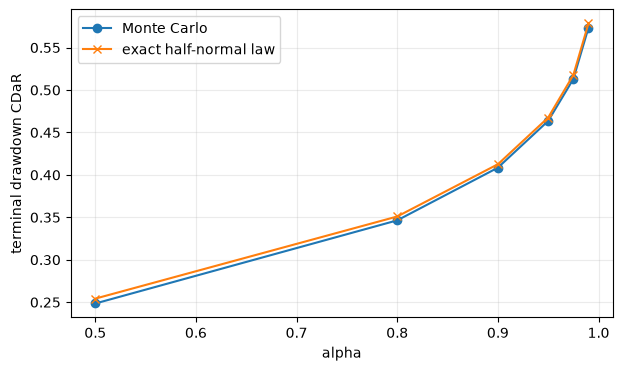

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(exact["alpha"], exact["mc_terminal_cdar"], marker="o", label="Monte Carlo")
ax.plot(exact["alpha"], exact["exact_terminal_cdar"], marker="x", label="exact half-normal law")
ax.set_xlabel("alpha"); ax.set_ylabel("terminal drawdown CDaR")
ax.legend(); ax.grid(alpha=.25); plt.show()


## 3. Finite-scenario convergence

In [5]:
conv = pd.read_csv(VAL / "cdar_scenario_convergence.csv")
conv


,paths,alpha,mc_terminal_cdar,exact_terminal_cdar,absolute_cdar_error,mc_terminal_var,exact_terminal_var,absolute_var_error
0,100,0.95,0.433958,0.467561,0.033602,0.350203,0.391993,0.041790
1,250,0.95,0.451794,0.467561,0.015766,0.352196,0.391993,0.039797
2,500,0.95,0.482292,0.467561,0.014731,0.416073,0.391993,0.024080
3,1000,0.95,0.484346,0.467561,0.016786,0.410805,0.391993,0.018812
4,2500,0.95,0.472448,0.467561,0.004887,0.400066,0.391993,0.008074
5,5000,0.95,0.472616,0.467561,0.005055,0.395344,0.391993,0.003351
6,10000,0.95,0.470023,0.467561,0.002463,0.391855,0.391993,0.000138
7,25000,0.95,0.463627,0.467561,0.003934,0.389830,0.391993,0.002163


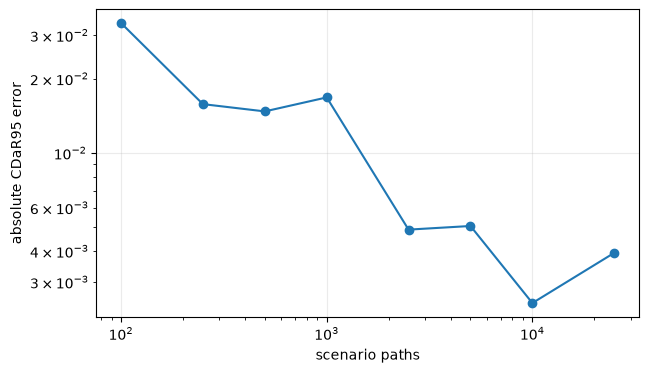

In [6]:
fig, ax = plt.subplots(figsize=(7,4))
ax.loglog(conv["paths"], conv["absolute_cdar_error"], marker="o")
ax.set_xlabel("scenario paths"); ax.set_ylabel("absolute CDaR95 error")
ax.grid(alpha=.25); plt.show()


## 4. CVaR–CDaR risk-geometry non-dominance

In [7]:
pd.read_csv(VAL / "cvar_cdar_ranking_reversal.csv")


,terminal_loss_a,terminal_loss_b,cdar_a,cdar_b,terminal_prefers_a,cdar_prefers_b
0,-0.0,0.05,0.2,0.05,1.0,1.0


## 5. Controlled sequential CDaR calibration

In [8]:
trials = pd.read_csv(CAL / "cdar_synthetic_calibration_trials.csv")
trials.sort_values(["selected_risk_control","annualized_test_return"], ascending=[False,False]).head(10)


,alpha,cdar_budget_mult,turnover_penalty,months_solved,mean_test_return,annualized_test_return,annualized_test_vol,test_sharpe_zero_rf,mean_test_cdar95,max_test_cdar95,mean_executed_turnover,mean_shadow_price,selected_risk_control,selected_max_return
19,0.950,1.00,0.006,18,0.000352,0.004227,0.012897,0.327782,0.047061,0.087533,0.104115,0.062244,True,False
10,0.900,1.15,0.003,18,0.000424,0.005089,0.014165,0.359253,0.052046,0.092451,0.315880,0.079571,False,True
22,0.950,1.15,0.003,18,0.000412,0.004945,0.014429,0.342741,0.052122,0.094806,0.328292,0.066160,False,False
9,0.900,1.15,0.001,18,0.000406,0.004875,0.012973,0.375740,0.050329,0.089592,0.501547,0.121386,False,False
34,0.975,1.15,0.003,18,0.000405,0.004854,0.014438,0.336214,0.052160,0.094867,0.332849,0.064086,False,False
21,0.950,1.15,0.001,18,0.000381,0.004567,0.013436,0.339859,0.050876,0.088537,0.491133,0.097431,False,False
33,0.975,1.15,0.001,18,0.000378,0.004534,0.013448,0.337157,0.051053,0.088633,0.505934,0.064935,False,False
35,0.975,1.15,0.006,18,0.000375,0.004496,0.013736,0.327276,0.048683,0.094443,0.138424,0.017381,False,False
8,0.900,1.15,0.000,18,0.000373,0.004472,0.012842,0.348225,0.050264,0.089582,0.577470,0.150529,False,False
23,0.950,1.15,0.006,18,0.000371,0.004456,0.013717,0.324893,0.048804,0.094236,0.141595,0.020446,False,False


In [9]:
summary = json.loads((CAL / "cdar_synthetic_calibration_summary.json").read_text())
summary


{'risk_control': {'alpha': 0.95,
  'cdar_budget_mult': 1.0,
  'turnover_penalty': 0.006,
  'months_solved': 18,
  'mean_test_return': 0.00035227019792285515,
  'annualized_test_return': 0.0042272423750742616,
  'annualized_test_vol': 0.01289650467170801,
  'test_sharpe_zero_rf': 0.32778202177120647,
  'mean_test_cdar95': 0.04706092336519951,
  'max_test_cdar95': 0.08753299757508765,
  'mean_executed_turnover': 0.10411546277545539,
  'mean_shadow_price': 0.062244381485594684,
  'selected_risk_control': True,
  'selected_max_return': False},
 'max_return': {'alpha': 0.9,
  'cdar_budget_mult': 1.15,
  'turnover_penalty': 0.003,
  'months_solved': 18,
  'mean_test_return': 0.00042407809867710364,
  'annualized_test_return': 0.005088937184125244,
  'annualized_test_vol': 0.01416531657913722,
  'test_sharpe_zero_rf': 0.35925333229899475,
  'mean_test_cdar95': 0.05204626076755448,
  'max_test_cdar95': 0.09245112098814304,
  'mean_executed_turnover': 0.3158800825733688,
  'mean_shadow_price': 

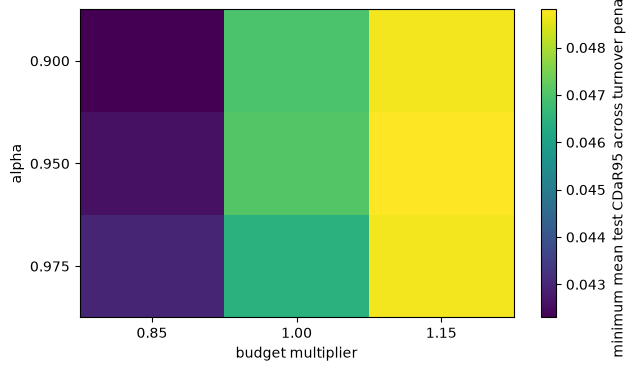

In [10]:
pivot = trials.pivot_table(index="alpha", columns="cdar_budget_mult", values="mean_test_cdar95", aggfunc="min")
fig, ax = plt.subplots(figsize=(7,4))
im=ax.imshow(pivot.to_numpy(), aspect="auto")
ax.set_xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns])
ax.set_yticks(range(len(pivot.index)), [f"{x:.3f}" for x in pivot.index])
ax.set_xlabel("budget multiplier"); ax.set_ylabel("alpha")
fig.colorbar(im, ax=ax, label="minimum mean test CDaR95 across turnover penalties")
plt.show()


## 6. Historical paired rerun (data-pending)

Once the frozen ETF data are available, run:

```bash
python -m scripts.runs.run --config-path bayessian_cvar_paired.yaml
python -m scripts.runs.run --config-path bayessian_cdar.yaml
python -m scripts.runs.compare_cvar_cdar --cvar-dir results/bayessian_cvar_paired_walk_forward --cdar-dir results/bayessian_cdar_walk_forward --output-dir results/cvar_cdar_comparison --block-length 6
```

The comparison must remain paired: identical dates, data vintage, seeds, universe, cost convention, execution, and non-risk-geometry settings.

In [11]:
PAIR = ROOT / "results" / "cvar_cdar_comparison"
if (PAIR / "cvar_cdar_metrics.csv").exists():
    display(pd.read_csv(PAIR / "cvar_cdar_metrics.csv"))
    display(pd.read_csv(PAIR / "cvar_cdar_paired_bootstrap.csv"))
    if (PAIR / "cvar_cdar_mechanism_summary.csv").exists():
        display(pd.read_csv(PAIR / "cvar_cdar_mechanism_summary.csv"))
else:
    print("Historical paired artifacts are not present in this archive; no ETF result is inferred from synthetic data.")


,arm,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Average Drawdown,Calmar Ratio,VaR (95%),...,Treynor Ratio,Tracking Error,Information Ratio,PSR,DSR,DSR Benchmark E[max SR],Number of Trials,Trial Sharpe Mean,Trial Sharpe Std,N Periods
0,CVaR,1.730704,0.154317,0.191240,0.744398,1.172081,-0.148479,-0.056546,1.039320,-0.073122,...,NaN,NaN,NaN,0.971472,0.971472,0.0,1.0,0.0,0.0,84.0
1,CDaR,1.706114,0.152826,0.176413,0.784581,1.253701,-0.142532,-0.051971,1.072218,-0.077268,...,NaN,NaN,NaN,0.976281,0.976281,0.0,1.0,0.0,0.0,84.0


,comparison,estimate,p_treatment_better,ci_2_5,ci_97_5
0,CDaR minus CVaR Sharpe,0.040183,0.816,-0.042351,0.117913
1,CDaR minus CVaR max drawdown (positive=shallower),0.005946,0.934,-0.005832,0.058103
